In [1]:
import numpy as np
from scipy.stats import norm, uniform
import matplotlib.pyplot as plt
import _fig_params

In [2]:
np.random.seed(3)

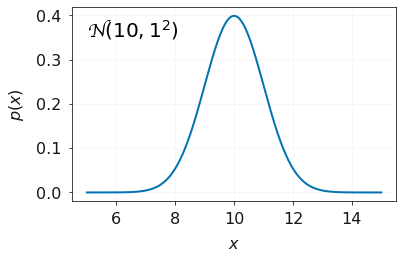

In [3]:
n = norm(loc=10, scale=1)
x = np.linspace(5, 15, 1000)
plt.plot(x, n.pdf(x))
plt.text(5, 0.35, '$\mathcal{N}(10, 1^2)$')
plt.xlabel('$x$')
plt.ylabel('$p(x)$')
plt.tight_layout()
plt.savefig('figures/px.png', dpi=600)

In [4]:
x = np.linspace(1, 9, 5)
y = 1.123 * x + 2.63 + (np.random.randn(5) * 0.5)
dy = np.ones(5)

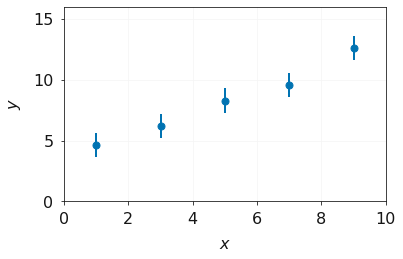

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(x, y, dy, marker='o', ls='')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_ylim(0, 16)
ax.set_xlim(0, 10)
plt.tight_layout()
plt.savefig('figures/data.png', dpi=600)

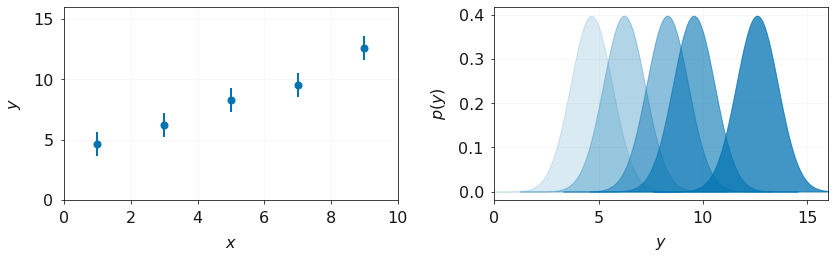

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].errorbar(x, y, dy, marker='o', ls='')
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$y$')
ax[0].set_ylim(0, 16)
ax[0].set_xlim(0, 10)
for i in range(len(y)):
    x_a = np.linspace(y[i] - 5 * dy[i], y[i] + 5 * dy[i], 100)
    ax[1].fill_between(x_a, 0, norm.pdf(x_a, loc=y[i], scale=dy[i]), 
                       alpha=0.15*(i+1), color=_fig_params.colors[0])
ax[1].set_xlabel('$y$')
ax[1].set_xlim(0, 16)
ax[1].set_ylabel('$p(y)$')
plt.tight_layout()
plt.savefig('figures/data_p.png', dpi=600)

In [7]:
def straight_line(x, m, c):
    return m * x + c

In [8]:
from scipy.optimize import curve_fit

In [22]:
popt, pcov = curve_fit(straight_line, x, y, sigma=dy)

In [23]:
popt, pcov

(array([0.9621991 , 3.45207998]),
 array([[ 0.00584365, -0.02921824],
        [-0.02921824,  0.19284036]]))

In [24]:
from scipy.stats import multivariate_normal

In [25]:
mv = multivariate_normal(mean=popt, cov=pcov)

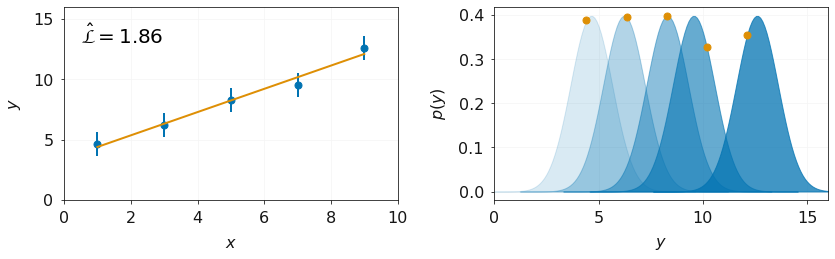

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].errorbar(x, y, dy, marker='o', ls='')
ax[0].plot(x, straight_line(x, *popt), zorder=10)
ax[0].set_xlabel('$x$')
ax[0].set_ylabel('$y$')
ax[0].set_ylim(0, 16)
ax[0].set_xlim(0, 10)
z = []
for i in range(len(y)):
    x_a = np.linspace(y[i] - 5 * dy[i], y[i] + 5 * dy[i], 100)
    ax[1].fill_between(x_a, 0, norm.pdf(x_a, loc=y[i], scale=dy[i]), 
                       alpha=0.15*(i+1), color=_fig_params.colors[0])
    z.append(norm.pdf(straight_line(x[i], *popt), loc=y[i], scale=dy[i]))
plt.plot(straight_line(x, *popt), z, 'o', c=_fig_params.colors[1])
ax[1].set_xlabel('$y$')
ax[1].set_xlim(0, 16)
ax[1].set_ylabel('$p(y)$')
ax[0].text(0.5, 13, r'$\hat{\mathcal{L}}=$' + '${:.2f}$'.format(np.sum(z)))
plt.tight_layout()
plt.savefig('figures/fitted.png', dpi=600)

In [46]:
import emcee

In [47]:
def log_likelihood(theta, x, y, yerr):
    m, b = theta
    model = m * x + b
    sigma2 = yerr ** 2 
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

In [107]:
pos = popt + 1e-1 * np.random.randn(32, 2)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood, args=(x, y, dy))
sampler.run_mcmc(pos, 5000, progress=True);

100%|██████████| 5000/5000 [00:06<00:00, 768.69it/s]


In [108]:
X, Y = np.meshgrid(np.linspace(0.7, 1.2, 100), np.linspace(2.5, 4.5, 100))

In [109]:
Z = np.zeros_like(X)
for i in range(100):
    for j in range(100):
        Z[j, i] = mv.pdf([np.linspace(0.7, 1.2, 100)[i], np.linspace(2.5, 4.5, 100)[j]])

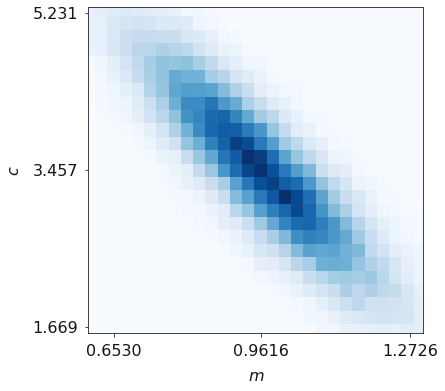

In [110]:
fig, ax = plt.subplots(figsize=(6, 6))
#ax.contour(X, Y, Z.T, colors='k')
hist = ax.hist2d(sampler.flatchain[:, 0], sampler.flatchain[:, 1], bins=50, cmap="Blues", density=True)
ax.set_xlim(0.6, 1.3)
ax.set_ylim(1.6, 5.3)
ax.set_xticks(np.percentile(sampler.flatchain[:, 0], [2.5, 50, 97.5]))
ax.set_yticks(np.percentile(sampler.flatchain[:, 1], [2.5, 50, 97.5]))
ax.set_xlabel('$m$')
ax.set_ylabel('$c$')
plt.savefig('figures/mcmc.png', dpi=600)
plt.show()

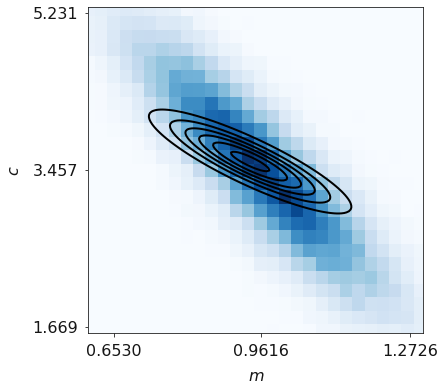

In [111]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.contour(X, Y, Z.T, colors='k')
hist = ax.hist2d(sampler.flatchain[:, 0], sampler.flatchain[:, 1], bins=50, cmap="Blues", density=True)
ax.set_xlim(0.6, 1.3)
ax.set_ylim(1.6, 5.3)
ax.set_xticks(np.percentile(sampler.flatchain[:, 0], [2.5, 50, 97.5]))
ax.set_yticks(np.percentile(sampler.flatchain[:, 1], [2.5, 50, 97.5]))
ax.set_xlabel('$m$')
ax.set_ylabel('$c$')
plt.savefig('figures/mcmc_c.png', dpi=600)
plt.show()

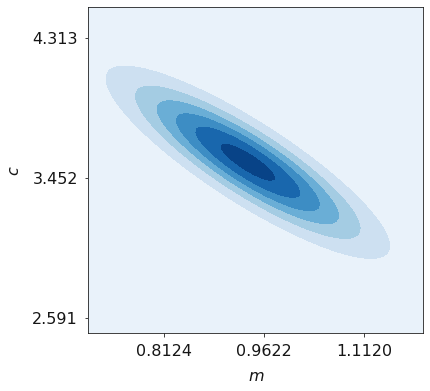

In [112]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.contourf(X, Y, Z.T, cmap='Blues')
ax.set_xlabel('$m$')
ax.set_ylabel('$c$')
ax.set_xlim(0.7, 1.2)
ax.set_ylim(2.5, 4.5)
ax.set_xticks([popt[0] - 1.96 * np.sqrt(pcov[0][0]), popt[0], popt[0] + 1.96 * np.sqrt(pcov[0][0])])
ax.set_yticks([popt[1] - 1.96 * np.sqrt(pcov[1][1]), popt[1], popt[1] + 1.96 * np.sqrt(pcov[1][1])])
plt.savefig('figures/curve_fit.png', dpi=600)
plt.show()

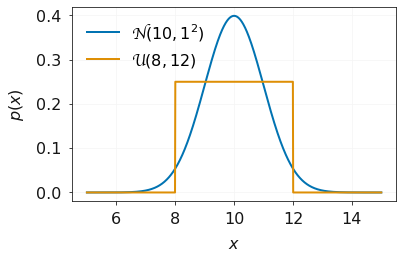

In [128]:
fig, ax = plt.subplots(figsize=(6, 4))
n = norm(loc=10, scale=1)
u = uniform(loc=8, scale=4)
x = np.linspace(5, 15, 1000)
ax.plot(x, n.pdf(x), label='$\mathcal{N}(10, 1^2)$')
ax.set_xlabel('$x$')
ax.set_ylabel('$p(x)$')
ax.plot(x, u.pdf(x), label='$\mathcal{U}(8, 12)$')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('figures/priors.png', dpi=600)